In [2]:
# STEP 1 & 2: Load data, verify dimensions, uniqueness check, and data types
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Telco-Customer-Churn.csv")

print("=== STEP 1 & 2 OUTPUT ===")
print(f"Rows and Columns: {df.shape}")
print(f"Total Values: {df.size}")
print(f"Distinct customerIDs: {df['customerID'].nunique()} (Uniqueness check: {'PASSED' if df['customerID'].nunique() == len(df) else 'FAILED'})")

print("\nData Types (df.dtypes):\n")
print(df.dtypes)

=== STEP 1 & 2 OUTPUT ===
Rows and Columns: (7043, 21)
Total Values: 147903
Distinct customerIDs: 7043 (Uniqueness check: PASSED)

Data Types (df.dtypes):

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [3]:
# Step 3 & 4: Missing Value Audit and Cleaning
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce')

# Identify rows with missing TotalCharges
missing_tc = df_clean[df_clean['TotalCharges'].isna()]
print(f"Blank TotalCharges cells: {len(missing_tc)}")
print(missing_tc[['customerID', 'tenure', 'Contract', 'Churn', 'TotalCharges']])

# Filter out rows with missing total charges or tenure == 0 for complete-case numerical evaluation
df_clean = df_clean.dropna(subset=['TotalCharges'])
print(f"\nCleaned dataset size: {len(df_clean)} rows\n")

df_clean.info()

Blank TotalCharges cells: 11
      customerID  tenure  Contract Churn  TotalCharges
488   4472-LVYGI       0  Two year    No           NaN
753   3115-CZMZD       0  Two year    No           NaN
936   5709-LVOEQ       0  Two year    No           NaN
1082  4367-NUYAO       0  Two year    No           NaN
1340  1371-DWPAZ       0  Two year    No           NaN
3331  7644-OMVMY       0  Two year    No           NaN
3826  3213-VVOLG       0  Two year    No           NaN
4380  2520-SGTTA       0  Two year    No           NaN
5218  2923-ARZLG       0  One year    No           NaN
6670  4075-WKNIU       0  Two year    No           NaN
6754  2775-SEFEE       0  Two year    No           NaN

Cleaned dataset size: 7032 rows

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-nu

In [4]:
# Step 5B: Categorical Columns Level & Count Summary
print("Categorical Columns Level & Count Summary (Step 5B):")
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
            'MultipleLines', 'InternetService', 'Contract', 'PaperlessBilling', 
            'PaymentMethod', 'Churn']

for col in cat_cols:
    val_counts = df[col].value_counts()
    summary_str = ", ".join([f"{k} ({v})" for k, v in val_counts.items()])
    print(f"{col + ':':<18} {summary_str}")

Categorical Columns Level & Count Summary (Step 5B):
gender:            Male (3555), Female (3488)
SeniorCitizen:     0 (5901), 1 (1142)
Partner:           No (3641), Yes (3402)
Dependents:        No (4933), Yes (2110)
PhoneService:      Yes (6361), No (682)
MultipleLines:     No (3390), Yes (2971), No phone service (682)
InternetService:   Fiber optic (3096), DSL (2421), No (1526)
Contract:          Month-to-month (3875), Two year (1695), One year (1473)
PaperlessBilling:  Yes (4171), No (2872)
PaymentMethod:     Electronic check (2365), Mailed check (1612), Bank transfer (automatic) (1544), Credit card (automatic) (1522)
Churn:             No (5174), Yes (1869)


In [5]:
# Step 6: Dataset Tail after Cleaning
print("=== STEP 6 OUTPUT: Dataset Tail after Cleaning ===")
display(df_clean.tail(7))
print(f"\n[{len(df_clean)} rows x {len(df_clean.columns)} columns; 11 missing TotalCharges entries excluded from numerical analysis]")

=== STEP 6 OUTPUT: Dataset Tail after Cleaning ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No



[7032 rows x 21 columns; 11 missing TotalCharges entries excluded from numerical analysis]


In [6]:
# Step 7: Numerical Summary Statistics
print("=== Summary Statistics (df.describe()) ===")
display(df_clean[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe())

=== Summary Statistics (df.describe()) ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
# Step 8: SeniorCitizen Breakdown
print("=== SeniorCitizen Breakdown (Step 8) ===")
sc_counts = df['SeniorCitizen'].value_counts()
sc_pcts = df['SeniorCitizen'].value_counts(normalize=True) * 100
sc_df = pd.DataFrame({
    'Category': ['Non-Senior (0)', 'Senior (1)'],
    'Count': [f"{sc_counts[0]:,}", f"{sc_counts[1]:,}"],
    'Percentage': [f"{sc_pcts[0]:.2f}%", f"{sc_pcts[1]:.2f}%"]
})
print(sc_df.to_string(index=False))

=== SeniorCitizen Breakdown (Step 8) ===
      Category Count Percentage
Non-Senior (0) 5,901     83.79%
    Senior (1) 1,142     16.21%


In [8]:
# Contract Type Frequency & Churn Rate Analysis
print("=== Contract Type Frequency & Churn Rate ===")
print("print(df_clean['Contract'].value_counts())")
print(df_clean['Contract'].value_counts())

print("\nChurn Rate by Contract Type:")
for contract in ['Month-to-month', 'One year', 'Two year']:
    total = len(df_clean[df_clean['Contract'] == contract])
    churned = len(df_clean[(df_clean['Contract'] == contract) & (df_clean['Churn'] == 'Yes')])
    pct = (churned / total) * 100
    print(f"{contract + ':':<16} {pct:.2f}% churn ({churned} / {total})")

=== Contract Type Frequency & Churn Rate ===
print(df_clean['Contract'].value_counts())
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Churn Rate by Contract Type:
Month-to-month:  42.71% churn (1655 / 3875)
One year:        11.28% churn (166 / 1472)
Two year:        2.85% churn (48 / 1685)


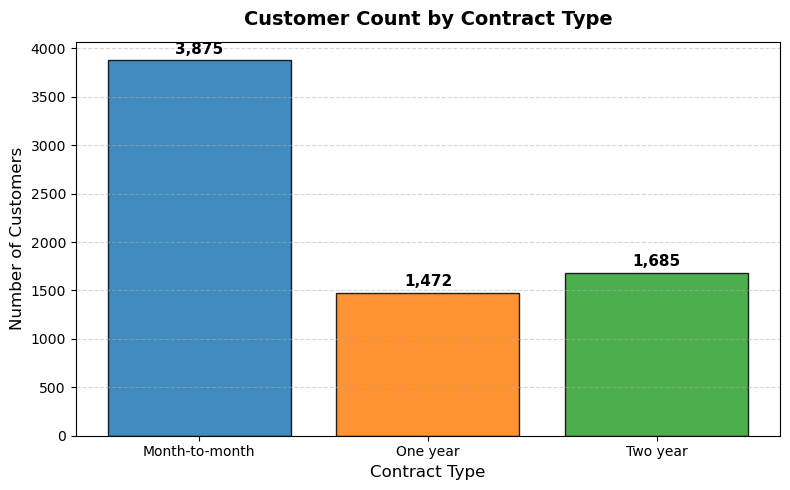

In [9]:
import matplotlib.pyplot as plt

# Bar chart: Customer Count by Contract Type
contracts = ['Month-to-month', 'One year', 'Two year']
counts = [df_clean['Contract'].value_counts()[c] for c in contracts]

plt.figure(figsize=(8, 5))
bars = plt.bar(contracts, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', alpha=0.85)
plt.title('Customer Count by Contract Type', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 40, f"{height:,}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

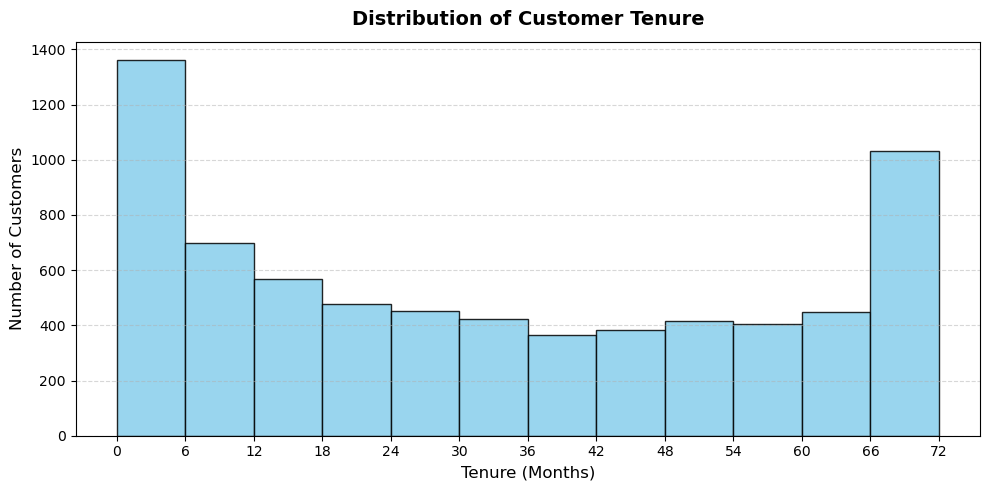

In [10]:
# Histogram: Distribution of Customer Tenure
plt.figure(figsize=(10, 5))
plt.hist(df_clean['tenure'], bins=range(0, 78, 6), edgecolor='black', color='skyblue', alpha=0.85)
plt.title('Distribution of Customer Tenure', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(range(0, 78, 6))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
# Step 9: Tenure Distribution Bins (6-month intervals)
print("=== Step 9 Output: Tenure Distribution Bins (6-month intervals) ===")
bins = range(0, 78, 6)
for i in range(len(bins)-1):
    low, high = bins[i], bins[i+1]
    count = len(df_clean[(df_clean['tenure'] >= low) & (df_clean['tenure'] < high if high < 72 else df_clean['tenure'] <= high)])
    print(f"{low:2d}-{high:2d} months: {count:5d} customers")

print("\nKey Peak Counts:")
print(f"Tenure = 1 month:   {len(df_clean[df_clean['tenure'] == 1]):>4d} customers")
print(f"Tenure = 72 months: {len(df_clean[df_clean['tenure'] == 72]):>4d} customers")

=== Step 9 Output: Tenure Distribution Bins (6-month intervals) ===
 0- 6 months:  1360 customers
 6-12 months:   698 customers
12-18 months:   568 customers
18-24 months:   479 customers
24-30 months:   453 customers
30-36 months:   423 customers
36-42 months:   364 customers
42-48 months:   384 customers
48-54 months:   416 customers
54-60 months:   404 customers
60-66 months:   450 customers
66-72 months:  1033 customers

Key Peak Counts:
Tenure = 1 month:    613 customers
Tenure = 72 months:  362 customers
